In [2]:
import pandas as pd

# Load the dataset using the Python engine
df = pd.read_csv(
    '/content/Airports2.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (653028, 15)


,Origin_airport,Destination_airport,Origin_city,Destination_city,Passengers,Seats,Flights,Distance,Fly_date,Origin_population,Destination_population,Org_airport_lat,Org_airport_long,Dest_airport_lat,Dest_airport_long
0,MHK,AMW,"Manhattan, KS","Ames, IA",21,30,1,254,2008-10-01,122049,86219,39.140999,-96.670799,NaN,NaN
1,EUG,RDM,"Eugene, OR","Bend, OR",41,396,22,103,1990-11-01,284093,76034,44.124599,-123.211998,44.254101,-121.150002
2,EUG,RDM,"Eugene, OR","Bend, OR",88,342,19,103,1990-12-01,284093,76034,44.124599,-123.211998,44.254101,-121.150002
3,EUG,RDM,"Eugene, OR","Bend, OR",11,72,4,103,1990-10-01,284093,76034,44.124599,-123.211998,44.254101,-121.150002
4,MFR,RDM,"Medford, OR","Bend, OR",0,18,1,156,1990-02-01,147300,76034,42.374199,-122.873001,44.254101,-121.150002


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Origin_airport', 'Destination_airport', 'Origin_city', 'Destination_city', 'Passengers', 'Seats', 'Flights', 'Distance', 'Fly_date', 'Origin_population', 'Destination_population', 'Org_airport_lat', 'Org_airport_long', 'Dest_airport_lat', 'Dest_airport_long']


In [4]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653028 entries, 0 to 653027
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Origin_airport          653028 non-null  object 
 1   Destination_airport     653028 non-null  object 
 2   Origin_city             653028 non-null  object 
 3   Destination_city        653028 non-null  object 
 4   Passengers              653028 non-null  int64  
 5   Seats                   653028 non-null  int64  
 6   Flights                 653028 non-null  int64  
 7   Distance                653028 non-null  int64  
 8   Fly_date                653028 non-null  object 
 9   Origin_population       653028 non-null  int64  
 10  Destination_population  653028 non-null  int64  
 11  Org_airport_lat         651326 non-null  float64
 12  Org_airport_long        651325 non-null  float64
 13  Dest_airport_lat        652395 non-null  float64
 14

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add edges using origin and destination airports
for _, row in df.iterrows():
    origin = row['Origin_airport']
    destination = row['Destination_airport']

    G.add_edge(
        origin,
        destination,
        flights=row['Flights'],
        passengers=row['Passengers'],
        distance=row['Distance']
    )

print("Graph created successfully!")

Graph created successfully!


In [6]:
print("Number of airports (nodes):", G.number_of_nodes())
print("Number of flight connections (edges):", G.number_of_edges())

Number of airports (nodes): 565
Number of flight connections (edges): 7114


In [7]:
print("\nFirst 10 airports:")
print(list(G.nodes())[:10])

print("\nFirst 10 connections:")
print(list(G.edges())[:10])


First 10 airports:
['MHK', 'AMW', 'EUG', 'RDM', 'MFR', 'SEA', 'PDX', 'LMT', 'SFO', 'LAX']

First 10 connections:
[('MHK', 'AMW'), ('MHK', 'HYS'), ('MHK', 'ACT'), ('MHK', 'CAK'), ('MHK', 'FAR'), ('MHK', 'MIA'), ('MHK', 'TMB'), ('MHK', 'OFF'), ('MHK', 'TUL'), ('MHK', 'AUS')]


In [8]:
# Basic graph information

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

print("Network density:", nx.density(G))

print("Is the graph connected?:", nx.is_connected(G))

Number of nodes: 565
Number of edges: 7114
Network density: 0.04464946965417686
Is the graph connected?: True


In [9]:
# Degree of each airport
degree = dict(G.degree())

# Sort airports by degree
top_airports = sorted(
    degree.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 airports by number of connections:")

for airport, connections in top_airports[:10]:
    print(airport, ":", connections)

Top 10 airports by number of connections:
DFW : 268
MIA : 248
ATL : 225
TUS : 221
DAL : 216
EWR : 210
DAY : 200
TUL : 198
LRD : 197
OMA : 196


In [14]:
# Create a DataFrame from the top 10 airports

top10_df = pd.DataFrame(
    top_airports[:10],
    columns=['Airport', 'Connections']
)

# Create categories based on number of connections
def categorize(connections):
    if connections >= 220:
        return 'High'
    elif connections >= 200:
        return 'Medium'
    else:
        return 'Low'

top10_df['Category'] = top10_df['Connections'].apply(categorize)

print(top10_df)

  Airport  Connections Category
0     DFW          268     High
1     MIA          248     High
2     ATL          225     High
3     TUS          221     High
4     DAL          216   Medium
5     EWR          210   Medium
6     DAY          200   Medium
7     TUL          198      Low
8     LRD          197      Low
9     OMA          196      Low


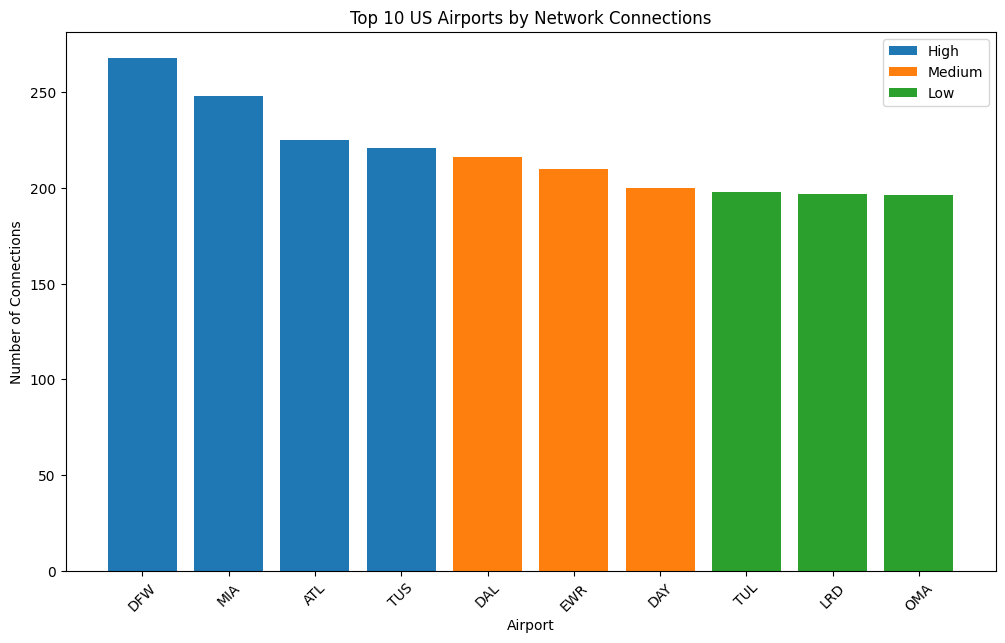

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for category in ['High', 'Medium', 'Low']:
    data = top10_df[top10_df['Category'] == category]

    plt.bar(
        data['Airport'],
        data['Connections'],
        label=category
    )

plt.xlabel('Airport')
plt.ylabel('Number of Connections')
plt.title('Top 10 US Airports by Network Connections')
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [16]:
# Get the top 10 airport names
top10_airports = top10_df['Airport'].tolist()

# Create a smaller network
G_top10 = G.subgraph(top10_airports).copy()

print("Number of nodes:", G_top10.number_of_nodes())
print("Number of edges:", G_top10.number_of_edges())

Number of nodes: 10
Number of edges: 54


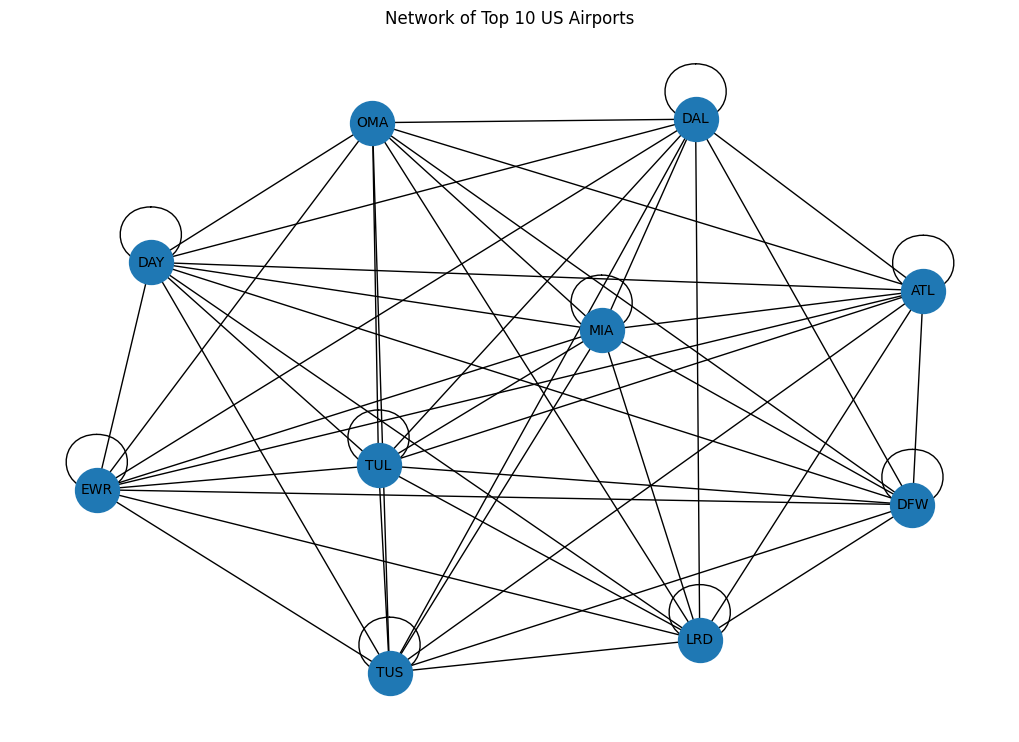

In [17]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G_top10, seed=42)

nx.draw(
    G_top10,
    pos,
    with_labels=True,
    node_size=1000,
    font_size=10
)

plt.title("Network of Top 10 US Airports")
plt.show()

In [18]:
# Add category information to each airport node

for _, row in top10_df.iterrows():
    G.nodes[row['Airport']]['Category'] = row['Category']
    G.nodes[row['Airport']]['Connections'] = row['Connections']

print("Category information added to graph successfully!")

Category information added to graph successfully!


In [19]:
# Create a subgraph containing only the top 10 airports

top10_airports = top10_df['Airport'].tolist()

G_top10 = G.subgraph(top10_airports).copy()

print("Top 10 graph created!")
print("Number of nodes:", G_top10.number_of_nodes())
print("Number of edges:", G_top10.number_of_edges())

Top 10 graph created!
Number of nodes: 10
Number of edges: 54


In [20]:
print("Is the top-10 graph connected?:", nx.is_connected(G_top10))

Is the top-10 graph connected?: True


In [21]:
# Add category and connection information to each node

for _, row in top10_df.iterrows():
    G_top10.nodes[row['Airport']]['Category'] = row['Category']
    G_top10.nodes[row['Airport']]['Connections'] = row['Connections']

print("Category information added successfully!")

Category information added successfully!


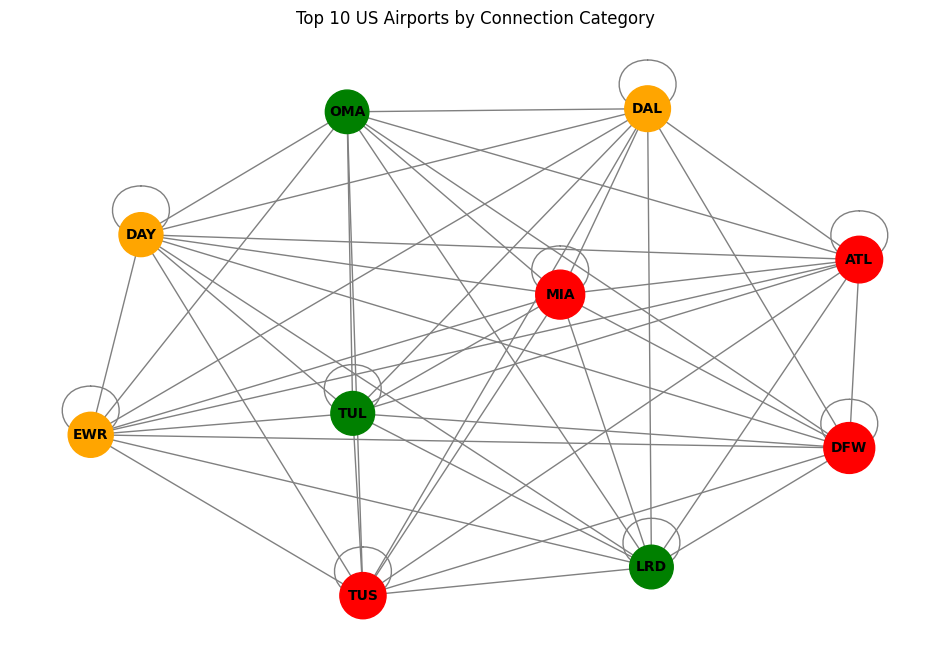

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

# Define colors for each category
category_colors = {
    'High': 'red',
    'Medium': 'orange',
    'Low': 'green'
}

# Assign color to each node
node_colors = [
    category_colors[G_top10.nodes[node]['Category']]
    for node in G_top10.nodes()
]

# Assign node size based on number of connections
node_sizes = [
    G_top10.nodes[node]['Connections'] * 5
    for node in G_top10.nodes()
]

# Create graph layout
pos = nx.spring_layout(G_top10, seed=42)

plt.figure(figsize=(12, 8))

nx.draw_networkx(
    G_top10,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    with_labels=True,
    font_size=10,
    font_weight='bold',
    edge_color='gray'
)

plt.title("Top 10 US Airports by Connection Category")
plt.axis('off')
plt.show()

In [23]:
print("Connections among the top 10 airports:")

for edge in G_top10.edges():
    print(edge)

Connections among the top 10 airports:
('DAL', 'MIA')
('DAL', 'OMA')
('DAL', 'TUL')
('DAL', 'DFW')
('DAL', 'DAY')
('DAL', 'ATL')
('DAL', 'LRD')
('DAL', 'EWR')
('DAL', 'DAL')
('DAL', 'TUS')
('ATL', 'MIA')
('ATL', 'OMA')
('ATL', 'TUL')
('ATL', 'DFW')
('ATL', 'DAY')
('ATL', 'LRD')
('ATL', 'EWR')
('ATL', 'TUS')
('ATL', 'ATL')
('EWR', 'MIA')
('EWR', 'OMA')
('EWR', 'TUL')
('EWR', 'DFW')
('EWR', 'DAY')
('EWR', 'LRD')
('EWR', 'TUS')
('EWR', 'EWR')
('DAY', 'MIA')
('DAY', 'OMA')
('DAY', 'TUL')
('DAY', 'DFW')
('DAY', 'DAY')
('DAY', 'TUS')
('DAY', 'LRD')
('MIA', 'DFW')
('MIA', 'MIA')
('MIA', 'OMA')
('MIA', 'TUL')
('MIA', 'TUS')
('MIA', 'LRD')
('OMA', 'TUS')
('OMA', 'TUL')
('OMA', 'DFW')
('OMA', 'LRD')
('DFW', 'TUL')
('DFW', 'TUS')
('DFW', 'LRD')
('DFW', 'DFW')
('TUS', 'TUL')
('TUS', 'LRD')
('TUS', 'TUS')
('TUL', 'LRD')
('TUL', 'TUL')
('LRD', 'LRD')


In [24]:
# Remove self-loops
G_top10.remove_edges_from(nx.selfloop_edges(G_top10))

print("Self-loops removed!")
print("Number of nodes:", G_top10.number_of_nodes())
print("Number of edges:", G_top10.number_of_edges())

Self-loops removed!
Number of nodes: 10
Number of edges: 45


In [25]:
print("Connections among the top 10 airports:")

for edge in G_top10.edges():
    print(edge)

Connections among the top 10 airports:
('DAL', 'MIA')
('DAL', 'OMA')
('DAL', 'TUL')
('DAL', 'DFW')
('DAL', 'DAY')
('DAL', 'ATL')
('DAL', 'LRD')
('DAL', 'EWR')
('DAL', 'TUS')
('ATL', 'MIA')
('ATL', 'OMA')
('ATL', 'TUL')
('ATL', 'DFW')
('ATL', 'DAY')
('ATL', 'LRD')
('ATL', 'EWR')
('ATL', 'TUS')
('EWR', 'MIA')
('EWR', 'OMA')
('EWR', 'TUL')
('EWR', 'DFW')
('EWR', 'DAY')
('EWR', 'LRD')
('EWR', 'TUS')
('DAY', 'MIA')
('DAY', 'OMA')
('DAY', 'TUL')
('DAY', 'DFW')
('DAY', 'TUS')
('DAY', 'LRD')
('MIA', 'DFW')
('MIA', 'OMA')
('MIA', 'TUL')
('MIA', 'TUS')
('MIA', 'LRD')
('OMA', 'TUS')
('OMA', 'TUL')
('OMA', 'DFW')
('OMA', 'LRD')
('DFW', 'TUL')
('DFW', 'TUS')
('DFW', 'LRD')
('TUS', 'TUL')
('TUS', 'LRD')
('TUL', 'LRD')


In [26]:
print("Is the top-10 graph connected?:", nx.is_connected(G_top10))

Is the top-10 graph connected?: True


In [27]:
print("Final Top-10 Airport Network")
print("----------------------------")
print("Nodes:", G_top10.number_of_nodes())
print("Edges:", G_top10.number_of_edges())
print("Density:", nx.density(G_top10))
print("Connected:", nx.is_connected(G_top10))

Final Top-10 Airport Network
----------------------------
Nodes: 10
Edges: 45
Density: 1.0
Connected: True


In [28]:
# Breadth-First Search (BFS)

bfs_order = list(nx.bfs_tree(G_top10, source='DFW').nodes())

print("BFS traversal starting from DFW:")
print(bfs_order)

BFS traversal starting from DFW:
['DFW', 'DAL', 'ATL', 'EWR', 'DAY', 'MIA', 'OMA', 'TUL', 'TUS', 'LRD']


In [29]:
# Depth-First Search (DFS)

dfs_order = list(nx.dfs_tree(G_top10, source='DFW').nodes())

print("DFS traversal starting from DFW:")
print(dfs_order)

DFS traversal starting from DFW:
['DFW', 'DAL', 'MIA', 'ATL', 'OMA', 'EWR', 'TUL', 'DAY', 'TUS', 'LRD']


In [30]:
print("BFS order:", bfs_order)
print("DFS order:", dfs_order)

print("\nNumber of airports visited by BFS:", len(bfs_order))
print("Number of airports visited by DFS:", len(dfs_order))

BFS order: ['DFW', 'DAL', 'ATL', 'EWR', 'DAY', 'MIA', 'OMA', 'TUL', 'TUS', 'LRD']
DFS order: ['DFW', 'DAL', 'MIA', 'ATL', 'OMA', 'EWR', 'TUL', 'DAY', 'TUS', 'LRD']

Number of airports visited by BFS: 10
Number of airports visited by DFS: 10


In [31]:
import pandas as pd

traversal_comparison = pd.DataFrame({
    'Position': range(1, 11),
    'BFS': bfs_order,
    'DFS': dfs_order
})

print(traversal_comparison)

   Position  BFS  DFS
0         1  DFW  DFW
1         2  DAL  DAL
2         3  ATL  MIA
3         4  EWR  ATL
4         5  DAY  OMA
5         6  MIA  EWR
6         7  OMA  TUL
7         8  TUL  DAY
8         9  TUS  TUS
9        10  LRD  LRD


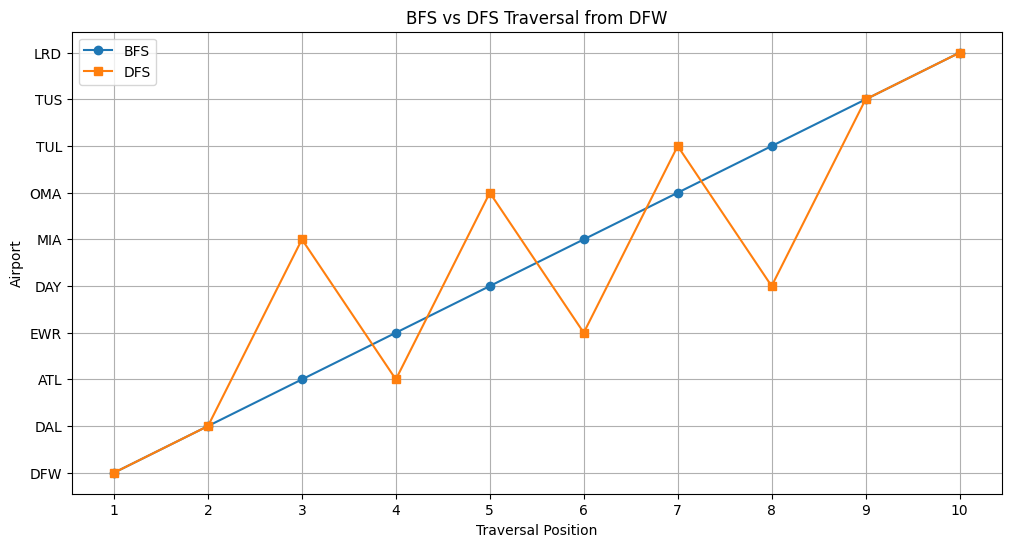

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    traversal_comparison['Position'],
    traversal_comparison['BFS'],
    marker='o',
    label='BFS'
)

plt.plot(
    traversal_comparison['Position'],
    traversal_comparison['DFS'],
    marker='s',
    label='DFS'
)

plt.xlabel('Traversal Position')
plt.ylabel('Airport')
plt.title('BFS vs DFS Traversal from DFW')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()

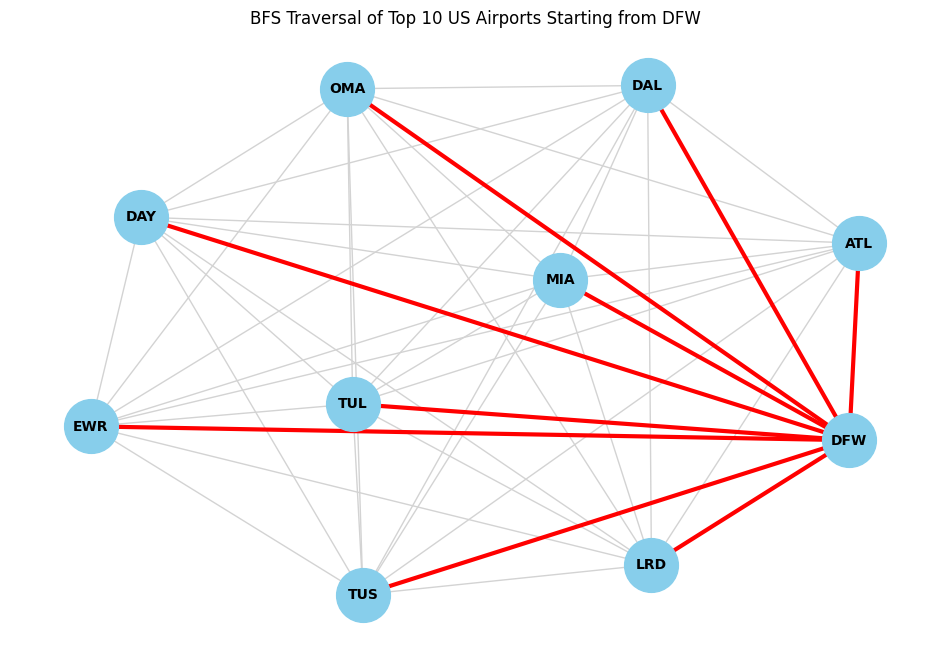

In [33]:
# Create BFS traversal graph

bfs_edges = list(nx.bfs_edges(G_top10, source='DFW'))

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G_top10, seed=42)

# Draw all network connections
nx.draw_networkx_edges(
    G_top10,
    pos,
    edge_color='lightgray',
    width=1
)

# Highlight BFS traversal
nx.draw_networkx_edges(
    G_top10,
    pos,
    edgelist=bfs_edges,
    edge_color='red',
    width=3
)

# Draw nodes
nx.draw_networkx_nodes(
    G_top10,
    pos,
    node_size=1500,
    node_color='skyblue'
)

# Labels
nx.draw_networkx_labels(
    G_top10,
    pos,
    font_size=10,
    font_weight='bold'
)

plt.title("BFS Traversal of Top 10 US Airports Starting from DFW")
plt.axis('off')
plt.show()

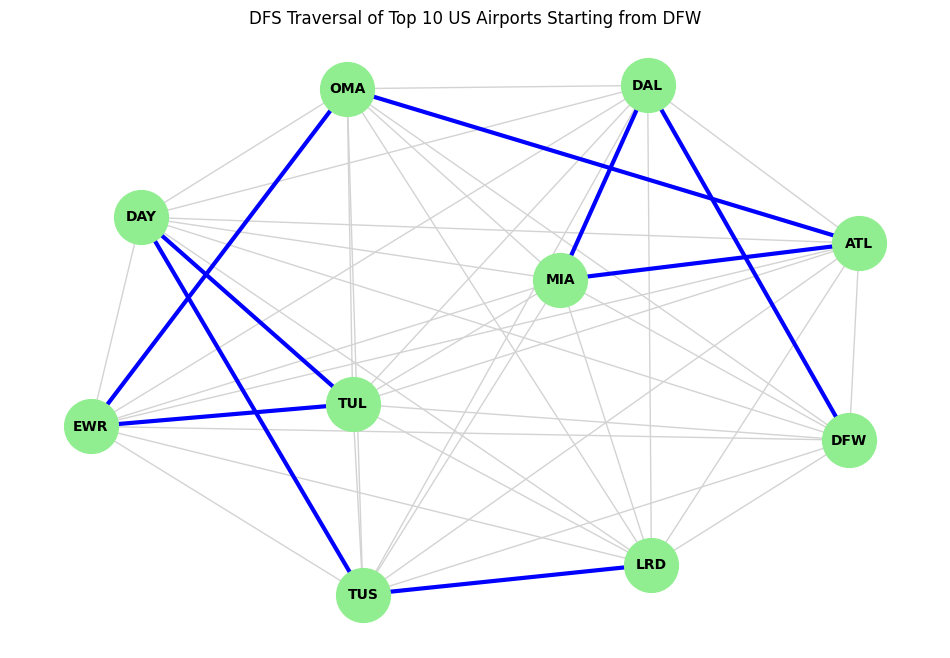

In [34]:
# Create DFS traversal graph

dfs_edges = list(nx.dfs_edges(G_top10, source='DFW'))

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G_top10, seed=42)

# Draw all network connections
nx.draw_networkx_edges(
    G_top10,
    pos,
    edge_color='lightgray',
    width=1
)

# Highlight DFS traversal
nx.draw_networkx_edges(
    G_top10,
    pos,
    edgelist=dfs_edges,
    edge_color='blue',
    width=3
)

# Draw nodes
nx.draw_networkx_nodes(
    G_top10,
    pos,
    node_size=1500,
    node_color='lightgreen'
)

# Labels
nx.draw_networkx_labels(
    G_top10,
    pos,
    font_size=10,
    font_weight='bold'
)

plt.title("DFS Traversal of Top 10 US Airports Starting from DFW")
plt.axis('off')
plt.show()

In [37]:
# Final graph measures

print("Top-10 Airport Network Analysis")
print("--------------------------------")
print("Number of nodes:", G_top10.number_of_nodes())
print("Number of edges:", G_top10.number_of_edges())
print("Network density:", nx.density(G_top10))
print("Is connected:", nx.is_connected(G_top10))

# Average degree
average_degree = sum(dict(G_top10.degree()).values()) / G_top10.number_of_nodes()

print("Average degree:", average_degree)

Top-10 Airport Network Analysis
--------------------------------
Number of nodes: 10
Number of edges: 45
Network density: 1.0
Is connected: True
Average degree: 9.0


In [38]:
# Degree centrality

degree_centrality = nx.degree_centrality(G_top10)

print("Degree Centrality:")
for airport, value in sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(airport, ":", round(value, 3))

Degree Centrality:
DAL : 1.0
ATL : 1.0
EWR : 1.0
DAY : 1.0
MIA : 1.0
OMA : 1.0
DFW : 1.0
TUS : 1.0
TUL : 1.0
LRD : 1.0


In [39]:
# Degree of each airport in the Top-10 graph

top10_degree = dict(G_top10.degree())

print("Airport connections in Top-10 graph:")

for airport, degree_value in sorted(
    top10_degree.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(airport, ":", degree_value)

Airport connections in Top-10 graph:
DAL : 9
ATL : 9
EWR : 9
DAY : 9
MIA : 9
OMA : 9
DFW : 9
TUS : 9
TUL : 9
LRD : 9


In [40]:
print("BFS vs DFS Comparison")
print("----------------------")

print("BFS traversal:")
print(" → ".join(bfs_order))

print("\nDFS traversal:")
print(" → ".join(dfs_order))

print("\nBFS nodes visited:", len(bfs_order))
print("DFS nodes visited:", len(dfs_order))

print("BFS traversal edges:", len(bfs_edges))
print("DFS traversal edges:", len(dfs_edges))

BFS vs DFS Comparison
----------------------
BFS traversal:
DFW → DAL → ATL → EWR → DAY → MIA → OMA → TUL → TUS → LRD

DFS traversal:
DFW → DAL → MIA → ATL → OMA → EWR → TUL → DAY → TUS → LRD

BFS nodes visited: 10
DFS nodes visited: 10
BFS traversal edges: 9
DFS traversal edges: 9


In [41]:
comparison_df = pd.DataFrame({
    'Measure': [
        'Starting Airport',
        'Nodes Visited',
        'Traversal Edges',
        'Traversal Method'
    ],
    'BFS': [
        'DFW',
        len(bfs_order),
        len(bfs_edges),
        'Level-by-level'
    ],
    'DFS': [
        'DFW',
        len(dfs_order),
        len(dfs_edges),
        'Depth-first'
    ]
})

comparison_df

,Measure,BFS,DFS
0,Starting Airport,DFW,DFW
1,Nodes Visited,10,10
2,Traversal Edges,9,9
3,Traversal Method,Level-by-level,Depth-first
